# Ergänzung zu Termin 1: Tensoren, Netzbausteine und der erste Trainingsschritt

In den Praktikumsaufgaben von Termin 1 klassifizieren Sie Fashion-MNIST-Bilder und sagen
Blütenmaße im Kirschblüten-Datensatz vorher, beides mit einem selbst trainierten Netz.
Kapitel 1 und 2 liefern dafür das Handwerkszeug: wie Tensoren Daten repräsentieren und wie
sich daraus ein Netz zusammensetzt. Hier gehen wir das in der Reihenfolge durch, in der Sie
es brauchen: von Form und Typ der Daten über die Bausteine eines Netzes bis zum eigentlichen
Trainingsschritt.

In [1]:
import matplotlib
import numpy
import torch

print(matplotlib.__version__)
print(numpy.__version__)

3.11.2
1.26.4


## 0. Setup

In [2]:
try:
    import torch, torchvision
    print(f"PyTorch {torch.__version__} und torchvision {torchvision.__version__} bereits vorhanden, kein Neuinstall noetig.")
except ImportError:
    !pip install -q torch torchvision

!pip install -q ipywidgets==8.1.9 scikit-learn==1.9.1 matplotlib==3.11.2 tqdm==4.70.1

PyTorch 2.4.0+cu124 und torchvision 0.19.0+cu124 bereits vorhanden, kein Neuinstall noetig.


## 1. Tensor-Ordnung, Form und Reshaping

Tensoren sind die Datencontainer, mit denen PyTorch operiert: Skalar, Vektor, Matrix und
ihre höherdimensionalen Verallgemeinerungen. Relevant für beide Aufgaben ist vor allem der
Übergang zwischen der "natürlichen" Form eines Datensatzes (Bilder als Höhe×Breite,
tabellarische Daten als Zeilen×Spalten) und der flachen Form, die eine `nn.Linear`-Schicht
erwartet.

In [3]:
import torch

beispieltensor = torch.arange(16).view(4, 4)
print(beispieltensor)
print(beispieltensor.view(-1, 16).shape)  # -1: die verbleibende Achse wird aus den übrigen Dimensionen abgeleitet

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]])
torch.Size([1, 16])


Dieselbe Operation begegnet Ihnen beim Übergang von einem Bild-Batch (Ordnung 3) auf die
flache Eingabe eines MLP:

`x.view(-1, 28*28)`.

Bei tabellarischen Daten entfällt dieser
Schritt meist, da die Merkmale bereits spaltenweise vorliegen. Dort ist stattdessen die
Achse der Beobachtungen von der Achse der Merkmale zu unterscheiden.

## 2. Numerische Typen: weshalb `float32` keine Formalität ist

Mit der richtigen Form allein ist es nicht getan, genauso wichtig ist der numerische Typ
der Werte darin. Rohdaten liegen häufig als Ganzzahl vor (Jahreszahlen, Pixelwerte,
Label-Indizes). PyTorch erlaubt Rückwärtsdifferentiation jedoch ausschließlich auf
Gleitkomma-Tensoren:

In [4]:
import numpy as np

x_int = torch.from_numpy(np.array([5, 3]))
try:
    x_int.requires_grad_(True)
except RuntimeError as fehler:
    print(fehler)

x_float = torch.from_numpy(np.array([5, 3]).astype(np.float32))
x_float.requires_grad_(True)
print(x_float)

only Tensors of floating point dtype can require gradients
tensor([5., 3.], requires_grad=True)


Ein `int64`-Tensor lässt sich weder differenzieren noch direkt durch eine
`nn.Linear`-Schicht führen. Ein explizites `astype(np.float32)` beim Einlesen ist daher
keine Stilfrage, sondern Voraussetzung für das spätere Training. Bei Bilddaten übernimmt
das meist schon `transforms.ToTensor()`; beim Einlesen einer CSV-Tabelle bleibt es
ein manueller Schritt.

## 3. `nn.Linear` als Parametrisierung und die Kosten der Netzbreite

Liegen die Daten in passender Form und passendem Typ vor, geht es als Nächstes um den
ersten Baustein des Netzes selbst: die lineare Schicht. Jede Schicht kombiniert Gewichte
und Bias zu einer neuen Repräsentation, gefolgt von einer Nichtlinearität. Dazu mehr in
Abschnitt 4. Gewichte und Bias sind die lernbaren Parameter, ihre Anzahl pro Schicht:
`Eingänge · Ausgänge + Ausgänge`.

In [5]:
import torch.nn as nn

schicht = nn.Linear(in_features=3, out_features=2)
print(sum(p.numel() for p in schicht.parameters()))  # (3*2) Gewichte + 2 Bias-Terme

8


Über zwei Schichten hinweg (Eingabe → versteckte Schicht → Ausgabe) ergibt die Summe
beider Terme die Gesamtparameterzahl. Mit dem Regler lässt sich vergleichen, welchen Hebel
welche Größe hat: Wie stark wächst die Parameterzahl, wenn nur `hidden_size` erhöht wird,
und wie stark, wenn stattdessen bei fester `hidden_size` die `in_features`
wachsen (dieselben Bezeichner wie im `nn.Linear`-Aufruf oben)? Voreingestellt sind die
Werte des Bildklassifikations-Netzes (784 `in_features`, 10 `out_features`); alle drei
Regler sind auf mindestens 1 begrenzt.

In [6]:
import ipywidgets as widgets
from IPython.display import clear_output


def parameterzahl(hidden_size, in_features, out_features):
    clear_output(wait=True)  # verhindert, dass sich mehrere Ausgaben untereinander ansammeln
    print(in_features * hidden_size + hidden_size + hidden_size * out_features + out_features)


widgets.interact(
    parameterzahl,
    hidden_size=widgets.IntSlider(min=1, max=256, value=2, description="hidden_size"),
    in_features=widgets.IntSlider(min=1, max=2000, value=784, description="in_features"),
    out_features=widgets.IntSlider(min=1, max=100, value=10, description="out_features"),
)

interactive(children=(IntSlider(value=2, description='hidden_size', max=256, min=1), IntSlider(value=784, desc…

<function __main__.parameterzahl(hidden_size, in_features, out_features)>

Der `in_features`-Term dominiert die Summe meist bei weitem. Das liegt nicht daran, dass er
pro Einheit stärker wirkt (`out_features` trägt sogar geringfügig mehr pro Einheit bei),
sondern daran, dass die Eingabedimension bei Bilddaten in der Praxis um Größenordnungen
höher liegt als die Anzahl der Ausgabeklassen.

## 4. Weshalb Nichtlinearität notwendig ist

Dass in Abschnitt 3 nach jeder linearen Schicht eine Nichtlinearität folgt, ist kein
Zufall: Zwei `nn.Linear`-Schichten direkt hintereinander lassen sich immer durch eine
einzige ersetzen. Ohne Nichtlinearität dazwischen bringt zusätzliche Tiefe also keinen
Gewinn:

In [7]:
torch.manual_seed(0)
schicht_a = nn.Linear(4, 4, bias=False)
schicht_b = nn.Linear(4, 4, bias=False)
x = torch.rand(1, 4)

verkettet = schicht_b(schicht_a(x))
kombiniert = x @ (schicht_b.weight @ schicht_a.weight).T
print((verkettet - kombiniert).abs().max().item())

7.450580596923828e-09


Die Differenz ist nur numerisches Rauschen, kein echter Unterschied. Beide Wege liefern
dasselbe Ergebnis. Beliebig viele verkettete lineare Schichten bleiben also immer
nur eine einzige lineare Abbildung, geometrisch eine Gerade bzw. Ebene. Ein rein lineares
Netz kann Klassen deshalb nur durch eine gerade Trennlinie unterscheiden und Zielwerte nur
durch eine Gerade annähern. Das reicht nicht für jedes Problem. Ein bekanntes Beispiel ist
XOR: Von vier Punkten gehören (0,0) und (1,1) zur einen, (0,1) und (1,0) zur anderen Klasse.
Keine einzige Gerade trennt diese beiden Klassen, egal wie sie gedreht wird. Erst eine
geknickte, nichtlineare Grenze schafft das. Dasselbe Problem träfe die beiden Aufgaben aus
Termin 1: Die drei Cluster im Klassifikationsbeispiel weiter unten liegen nicht so, dass
eine einzige Gerade sie sauber trennt, und die Zielkurve im Regressionsbeispiel ist keine
Gerade, sondern eine Sinuskurve. Nichtlinearität ist also notwendig, damit das Netz solche
gekrümmten Grenzen bzw. Kurven überhaupt abbilden kann. Termin 1 setzt dafür an zwei
Stellen unterschiedliche Funktionen ein, ReLU in der versteckten Schicht und Sigmoid am
Ausgang:

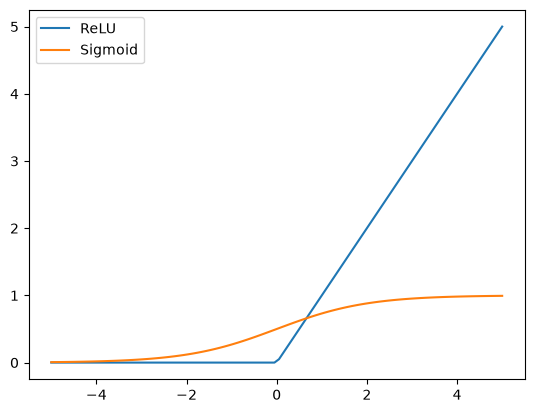

In [8]:
import matplotlib.pyplot as plt

x_werte = torch.linspace(-5, 5, 100)
plt.plot(x_werte.numpy(), torch.relu(x_werte).numpy(), label="ReLU")
plt.plot(x_werte.numpy(), torch.sigmoid(x_werte).numpy(), label="Sigmoid")
plt.legend()
plt.show()

ReLU lässt positive Eingaben unverändert durch und setzt alles Negative auf 0. Der Knick
bei 0 erzeugt genau den Bruch mit der Linearität, den eine reine Verkettung von
`nn.Linear`-Schichten nicht liefert. Sigmoid staucht dagegen beliebig große oder kleine
Eingaben auf das Intervall zwischen 0 und 1 und bildet damit direkt auf einen
Wahrscheinlichkeits- bzw. Anteilswert ab.

Das erklärt auch, wo welche Funktion eingesetzt wird: Im Klassifikationsnetz übernimmt
`CrossEntropyLoss` das Stauchen auf einen Wahrscheinlichkeitswert bereits selbst. Es
wendet intern eine Softmax auf die Ausgabe an, ReLU dient dort nur als Aktivierung der
versteckten Schicht. Im Regressionsnetz wird der Zielwert vorab auf 0 bis 1 skaliert,
deshalb passt Sigmoid am Ausgang zum Wertebereich des Ziels.

## 5. Sequential- versus Modul-basierte Definition

Lineare Schichten und Nichtlinearitäten abwechselnd aneinanderzureihen ergibt bereits ein
vollständiges Netz. Offen ist nur noch, wie sich diese Abfolge in PyTorch definieren lässt.
Beide Definitionsstile erzeugen hier dieselbe Berechnung; der Unterschied liegt darin,
wie viel Kontrolle über den Datenfluss die Definition erlaubt:

In [9]:
sequential = nn.Sequential(nn.Linear(3, 2), nn.ReLU(), nn.Linear(2, 1), nn.Sigmoid())


class Modul(nn.Module):
    def __init__(self):
        super().__init__()
        self.eins = nn.Linear(3, 2)
        self.zwei = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.zwei(torch.relu(self.eins(x))))


print(sequential)
print(Modul())

Sequential(
  (0): Linear(in_features=3, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
  (3): Sigmoid()
)
Modul(
  (eins): Linear(in_features=3, out_features=2, bias=True)
  (zwei): Linear(in_features=2, out_features=1, bias=True)
)


`nn.Sequential` reicht für starre, lineare Ketten.

Legt erst die Laufzeit die
Schichtstruktur fest, etwa über eine variable Liste versteckter Schichten, braucht es
stattdessen den Modul-Ansatz mit einer Schleife in `__init__` und `forward`.

### !!! Wichtig !!!
Landen die
Schichten dabei in einer gewöhnlichen Python-Liste statt in `nn.ModuleList`, registriert
PyTorch ihre Parameter nicht mit. Das ist ein leicht zu übersehender Fehler bei dynamisch
aufgebauten Netzen.

## 6. Trainingsschritt: Criterion und Optimizer

Mit einer der beiden Definitionsformen aus Abschnitt 5 steht die Netzarchitektur. Ihre
Gewichte sind aber noch zufällig initialisiert, die Vorhersagen entsprechend beliebig. Das
Ziel des Trainings: die Gewichte so verändern, dass die Vorhersage des Modells für jeden
Datenpunkt möglichst nah an das tatsächliche Label bzw. den tatsächlichen Zielwert
herankommt. Dafür braucht es zwei Bausteine.

Die Verlustfunktion (Criterion) misst diesen Abstand als eine einzelne Zahl. Sagt das
Klassifikationsnetz weiter unten für einen Punkt Klasse 2 vorher, obwohl er zu Klasse 0
gehört, liefert `CrossEntropyLoss` einen hohen Wert; trifft die Vorhersage die richtige
Klasse, einen niedrigen. Beim Regressionsnetz misst `MSELoss` entsprechend den quadrierten
Abstand zwischen vorhergesagtem und tatsächlichem Zahlenwert: je weiter die Vorhersage
daneben liegt, desto größer die Zahl.

Der Optimizer verändert anschließend die Gewichte so, dass genau dieser Wert beim nächsten
Versuch kleiner wird; in welche Richtung, verraten die Gradienten, die `backward()`
berechnet. Welche Kombination aus Criterion und Optimizer passt, hängt vom Problem ab: Das
folgende Beispiel durchläuft den Trainingsschritt zunächst für die Klassifikation auf
synthetischen Cluster-Daten mit `CrossEntropyLoss` und `SGD`, danach dieselbe Sequenz für
die Regression auf einer synthetischen Kurve mit `MSELoss` und `Adam`. Der Plot am Ende
jedes Beispiels zeigt den Verlust über die Trainings-Epochen: Fällt er, nähert sich das
Modell tatsächlich diesem Ziel an.

Unabhängig vom Problem läuft der eigentliche Trainingsschritt immer in derselben
Reihenfolge ab: `zero_grad()` löscht zunächst die Gradienten aus dem vorigen Schritt, der
Forward Pass berechnet die Modellausgabe, `backward()` bestimmt daraus die Gradienten aller
Parameter, und `step()` aktualisiert sie entsprechend. Fehlt `zero_grad()`, addieren sich
die Gradienten über mehrere Schritte hinweg auf, statt bei jedem Schritt neu bestimmt zu
werden. Das Modell wird dann mit falschen, zunehmend zu großen Gradienten aktualisiert.

Als Beispiel dient hier bewusst ein kleiner synthetischer Datensatz statt der echten
Fashion-MNIST-Bilder, damit sich der Trainingsschritt in Sekunden statt Minuten
nachvollziehen lässt: `make_blobs` erzeugt 90 zweidimensionale Punkte, die um drei Zentren
gestreut sind. `x_c` enthält die Koordinaten dieser Punkte, `y_c` das zugehörige Cluster als
Ganzzahl 0, 1 oder 2, das Label, genau wie die Klassennummer im Bildklassifikationsnetz.
Trainiert wird also, aus den zwei Koordinaten eines Punkts die richtige der drei Klassen
vorherzusagen.

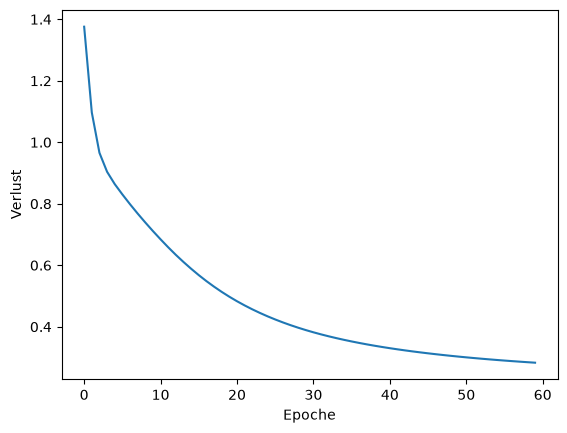

In [10]:
from sklearn.datasets import make_blobs

punkte, klassen = make_blobs(n_samples=90, centers=3, n_features=2, random_state=0)
x_c = torch.from_numpy(punkte.astype(np.float32))
y_c = torch.from_numpy(klassen.astype(np.int64))


class Klassifikator(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 3)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))


modell = Klassifikator(hidden_size=8)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(modell.parameters(), lr=0.1)

verlauf = []
for _ in range(60):
    optimizer.zero_grad()
    verlust = loss_fn(modell(x_c), y_c)
    verlust.backward()
    optimizer.step()
    verlauf.append(verlust.item())

plt.plot(verlauf)
plt.xlabel("Epoche")
plt.ylabel("Verlust")
plt.show()

Wie angekündigt läuft dieselbe Sequenz auch für das Regressionsproblem, nur mit `MSELoss`
und `Adam` statt `CrossEntropyLoss` und `SGD`. Der Unterschied zur Klassifikation liegt in
der Art der Zielgröße: Bei der Klassifikation gibt es eine feste, endliche Anzahl möglicher
Antworten, der Punkt aus Abschnitt 6 gehörte zu genau einem von drei Clustern, nie zu
einem Zwischending. Bei der Regression dagegen ist die Zielgröße eine kontinuierliche Zahl
aus einem Wertebereich, hier ein Punkt auf einer Kurve. Die Vorhersage kann näher oder
weiter am Zielwert liegen, aber es gibt kein einfaches richtig oder falsch mehr.

Auch hier steht eine synthetische Kurve stellvertretend für die echten Kirschblüten-Daten:
`x_r` sind 80 gleichmäßig verteilte Punkte zwischen 0 und 1, `y_r` der zugehörige, leicht
verrauschte Zielwert einer Sinuskurve. Trainiert wird also, für jedes `x_r` einen
Zahlenwert möglichst nah an `y_r` vorherzusagen. Adam adaptiert die Schrittweite pro
Parameter individuell und konvergiert bei kleinen Datensätzen in der Regel schneller, kann
dabei aber leichter in einem ungünstigen lokalen Minimum verbleiben als SGD.

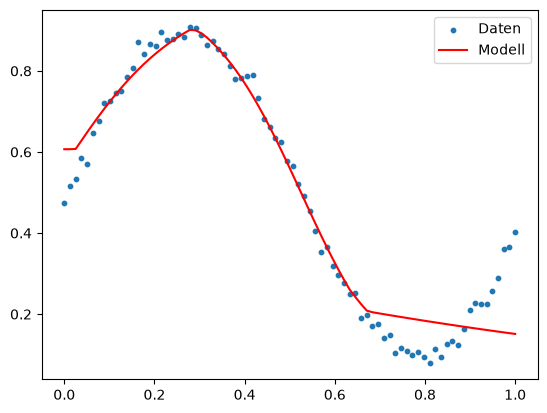

In [11]:
x_r = torch.linspace(0, 1, 80).view(-1, 1)
y_r = 0.5 + 0.4 * torch.sin(x_r * 6) + 0.02 * torch.randn_like(x_r)


class Regressor(nn.Module):
    def __init__(self, input_size, layers, output_size):
        super().__init__()
        module_liste, letzte_breite = [], input_size
        for breite in layers:
            module_liste.append(nn.Linear(letzte_breite, breite))
            letzte_breite = breite
        self.hidden = nn.ModuleList(module_liste)
        self.output = nn.Linear(letzte_breite, output_size)

    def forward(self, x):
        for schicht in self.hidden:
            x = torch.relu(schicht(x))
        return torch.sigmoid(self.output(x))


regressor = Regressor(input_size=1, layers=[16, 8], output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(regressor.parameters(), lr=1e-2)

for _ in range(300):
    optimizer.zero_grad()
    verlust = criterion(regressor(x_r), y_r)
    verlust.backward()
    optimizer.step()

plt.scatter(x_r, y_r, s=10, label="Daten")
plt.plot(x_r, regressor(x_r).detach(), color="red", label="Modell")
plt.legend()
plt.show()

## 7. Vorhersage und Auswertung: gehört ein Punkt zum richtigen Cluster?

Mit dem in Abschnitt 6 trainierten Klassifikationsmodell lässt sich jetzt tatsächlich
vorhersagen, zu welchem Cluster ein Punkt gehört, und prüfen, ob das stimmt. `modell(...)`
liefert für einen Punkt drei Werte, einen pro Klasse; `argmax` wählt die Klasse mit dem
höchsten Wert als Vorhersage.

In [12]:
test_index = 0
test_punkt = x_c[test_index:test_index + 1]
vorhersage = modell(test_punkt).argmax(dim=1).item()
print(f"Punkt {punkte[test_index]}: vorhergesagtes Cluster {vorhersage}, tatsächliches Cluster {klassen[test_index]}")

Punkt [-1.59514562  4.63122498]: vorhergesagtes Cluster 2, tatsächliches Cluster 2


Für diesen einen Punkt lässt sich Vorhersage und tatsächliches Label direkt vergleichen.
Ob das Modell zuverlässig richtig liegt, zeigt sich aber erst über mehrere Punkte hinweg:

In [13]:
alle_vorhersagen = modell(x_c).argmax(dim=1)
genauigkeit = (alle_vorhersagen == y_c).float().mean()
print(f"Genauigkeit über alle {len(x_c)} Punkte: {genauigkeit.item():.1%}")

Genauigkeit über alle 90 Punkte: 93.3%


`alle_vorhersagen == y_c` vergleicht Vorhersage und Label punktweise, `float().mean()`
fasst diese Treffer/Fehltreffer zu einem einzigen Anteilswert zusammen: der Genauigkeit.
Das ist dieselbe Größe, die in den Praktikumsaufgaben als `train_acc`/`test_acc` mitgeführt
wird, hier nur für das gesamte, kleine Beispiel auf einmal statt batchweise berechnet.

## 8. Vorhersage und Auswertung: wie nah liegt die Regression am Zielwert?

Genau hier zeigt sich der Unterschied aus der Einleitung zu Abschnitt 6 ganz konkret: Für
einen einzelnen Punkt lässt sich Vorhersage und Zielwert vergleichen, aber "richtig" im
Sinne von exakter Übereinstimmung gibt es praktisch nie.

In [14]:
test_index_r = 40
test_x = x_r[test_index_r:test_index_r + 1]
vorhersage_r = regressor(test_x).item()
print(f"x = {test_x.item():.3f}: vorhergesagt {vorhersage_r:.3f}, tatsächlich {y_r[test_index_r].item():.3f}")

x = 0.506: vorhergesagt 0.545, tatsächlich 0.566


Vorhersage und Zielwert liegen nah beieinander, aber nicht exakt gleich. Bei einer
kontinuierlichen Zielgröße ist das der Normalfall. Statt einer Trefferquote wie bei der
Klassifikation braucht es deshalb ein Maß für den Abstand, gemittelt über alle Punkte:

In [15]:
mittlerer_fehler = (regressor(x_r) - y_r).abs().mean()
print(f"Mittlerer Fehler über alle {len(x_r)} Punkte: {mittlerer_fehler.item():.3f}")

Mittlerer Fehler über alle 80 Punkte: 0.042


Dieser mittlere absolute Fehler ist das Gegenstück zur Genauigkeit aus Abschnitt 7, nur
für kontinuierliche statt diskreter Zielwerte. Genau das ist der Kern des Unterschieds
zwischen den beiden Problemtypen: Bei der Klassifikation wird ausgewertet, ob die richtige
von endlich vielen Klassen getroffen wurde; bei der Regression, wie weit die Vorhersage von
einem beliebigen Zahlenwert entfernt liegt.

## 9. Geräteabhängigkeit

Sowohl das Training in Abschnitt 6 als auch die Auswertung in Abschnitt 7 und 8 liefen
bislang ohne Rücksicht darauf, ob eine GPU zur Verfügung steht. Modell und Daten blieben
durchgehend auf der CPU. Ein fest kodiertes `.cuda()` bricht jedoch auf Systemen ohne
kompatible GPU ab. Die geräteunabhängige Variante:

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modell_d = Klassifikator(hidden_size=8).to(device)
print(modell_d(x_c.to(device)).shape)

torch.Size([90, 3])


Für Modellgrößen wie hier (< 2.000 Parameter, wenige Dutzend bis wenige hundert
Beobachtungen) spielt CPU versus GPU kaum eine Rolle; das ändert sich erst bei deutlich
größeren Architekturen und Datenmengen, wie sie in späteren Terminen auftreten.

## 10. Zusammenfassung

- `x.view(...)` übersetzt zwischen der "natürlichen" Form der Daten und der flachen
  Eingabe einer `nn.Linear`-Schicht.
- Numerische Typen vor dem Training explizit auf Gleitkomma setzen.
- Parameterzahl einer `nn.Linear`-Schicht: Eingänge · Ausgänge + Ausgänge.
- Ohne Nichtlinearität zwischen den Schichten ist Tiefe irrelevant.
- Modul-Ansatz statt `Sequential`, sobald die Architektur parametrisiert wird;
  `nn.ModuleList` für dynamisch erzeugte Schichtlisten.
- Trainingsschritt, unabhängig vom Problem: `zero_grad()` → Forward Pass → `backward()` →
  `step()`.
- Klassifikation vs. Regression bei der Auswertung: `argmax` liefert die vorhergesagte
  Klasse, der Anteil korrekter Vorhersagen die Genauigkeit; bei kontinuierlichen
  Zielwerten tritt an deren Stelle ein gemittelter Abstand wie der mittlere absolute Fehler.
- `torch.device` statt fest kodiertem `.cuda()`.